# Remove Text Annotations from Original Images using OCR


In [46]:
import numpy as np
import cv2
import os
import glob
import matplotlib.pyplot as plt
import keras_ocr
import math


In [47]:
original_path = "/hpcstor6/scratch01/a/a.kanamarlapudi001/synthetic_classifier/data_10samples/original_wl"
original_files = sorted(glob.glob(os.path.join(original_path, "*.png")))
print(f"Found {len(original_files)} images")


Found 10 images


In [48]:
# Setup OCR pipeline
pipeline = keras_ocr.pipeline.Pipeline()
print("OCR pipeline loaded!")


Looking for /home/a.kanamarlapudi001/.keras-ocr/craft_mlt_25k.h5
Looking for /home/a.kanamarlapudi001/.keras-ocr/crnn_kurapan.h5
OCR pipeline loaded!


In [49]:
# Function to detect breast region in the image
def detect_breast_region(img):
    # Breast tissue is brighter than black background
    # Use thresholding to find bright regions
    threshold_value = 25  # Pixels above this are likely breast tissue
    _, breast_mask = cv2.threshold(img, threshold_value, 255, cv2.THRESH_BINARY)
    
    # Clean up the mask with morphological operations
    kernel = np.ones((5, 5), np.uint8)
    breast_mask = cv2.morphologyEx(breast_mask, cv2.MORPH_CLOSE, kernel)
    breast_mask = cv2.morphologyEx(breast_mask, cv2.MORPH_OPEN, kernel)
    
    # Find the largest connected component (the breast)
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(breast_mask, connectivity=8)
    
    if num_labels > 1:
        # Find the largest component (skip background which is usually label 0)
        largest_label = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
        breast_mask = (labels == largest_label).astype(np.uint8) * 255
    
    return breast_mask

# Function to check if annotation overlaps with breast tissue
def check_breast_overlap(x_min, y_min, x_max, y_max, breast_mask, overlap_threshold=0.1):
    # Extract the region of the annotation box
    x_min = max(0, int(x_min))
    x_max = min(breast_mask.shape[1], int(x_max))
    y_min = max(0, int(y_min))
    y_max = min(breast_mask.shape[0], int(y_max))
    
    annotation_region = breast_mask[y_min:y_max, x_min:x_max]
    
    # Calculate overlap percentage
    annotation_area = (x_max - x_min) * (y_max - y_min)
    if annotation_area == 0:
        return False
    
    overlap_area = np.sum(annotation_region > 0)
    overlap_ratio = overlap_area / annotation_area
    
    # If more than threshold overlaps with breast tissue, skip removal
    return overlap_ratio > overlap_threshold

# Function to remove text annotations using OCR with breast detection
def midpoint(x1, y1, x2, y2):
    x_mid = int((x1 + x2) / 2)
    y_mid = int((y1 + y2) / 2)
    return (x_mid, y_mid)

def remove_text_annotations(img, pipeline):
    h, w = img.shape
    cleaned = img.copy()
    
    # First, detect where the breast tissue is
    breast_mask = detect_breast_region(img)
    
    # Convert to RGB if grayscale (keras-ocr needs RGB)
    if len(img.shape) == 2:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    else:
        img_rgb = img.copy()
    
    # Detect text using OCR
    prediction_groups = pipeline.recognize([img_rgb])
    
    # Define safe regions where text annotations typically appear - strict corner/edge only
    corner_h = 200
    corner_w = 250
    
    # Create mask for detected text regions - only remove text in safe corner/edge areas
    mask = np.zeros(img_rgb.shape[:2], dtype="uint8")
    
    # For each detected text box, check if it's safe to remove
    for box in prediction_groups[0]:
        # Get bounding box coordinates
        x_coords = [box[1][0][0], box[1][1][0], box[1][2][0], box[1][3][0]]
        y_coords = [box[1][0][1], box[1][1][1], box[1][2][1], box[1][3][1]]
        
        # Get bounding box boundaries
        x_min = min(x_coords)
        x_max = max(x_coords)
        y_min = min(y_coords)
        y_max = max(y_coords)
        
        # Extra safety: check if text box is too large (might be breast tissue)
        box_width = x_max - x_min
        box_height = y_max - y_min
        if box_width > 150 or box_height > 150:
            continue
        
        # Check if text is in corner/edge regions
        in_top_left = y_max < corner_h and x_max < corner_w
        in_top_right = y_max < corner_h and x_min > (w - corner_w)
        in_bottom_left = y_min > (h - corner_h) and x_max < corner_w
        in_bottom_right = y_min > (h - corner_h) and x_min > (w - corner_w)
        in_top_edge = y_max < 150 and corner_w <= x_min and x_max <= (w - corner_w)
        in_left_edge = x_max < 150 and corner_h <= y_min and y_max <= (h - corner_h)
        in_right_edge = x_min > (w - 150) and corner_h <= y_min and y_max <= (h - corner_h)
        
        in_safe_region = in_top_left or in_top_right or in_bottom_left or in_bottom_right or in_top_edge or in_left_edge or in_right_edge
        
        # If NOT in a safe corner/edge region, check if it's in center region (protect breast tissue)
        if not in_safe_region:
            center_x = (x_min + x_max) / 2
            center_y = (y_min + y_max) / 2
            
            # Skip if text center is in the middle 60% of image
            if (center_x > 0.2 * w and center_x < 0.8 * w) and (center_y > 0.2 * h and center_y < 0.8 * h):
                continue
        
        # Smart check: only remove if in safe region AND doesn't overlap with breast tissue
        if in_safe_region:
            # Check if annotation overlaps with breast tissue
            if check_breast_overlap(x_min, y_min, x_max, y_max, breast_mask, overlap_threshold=0.1):
                # Overlaps with breast tissue - skip removal to protect breast content
                continue
            
            # Safe to remove - create mask for this annotation
            x0, y0 = box[1][0]
            x1, y1 = box[1][1] 
            x2, y2 = box[1][2]
            x3, y3 = box[1][3]
            
            x_mid0, y_mid0 = midpoint(x1, y1, x2, y2)
            x_mid1, y_mid1 = midpoint(x0, y0, x3, y3)
            
            # Make thickness thicker and add padding to ensure complete removal
            thickness = int(math.sqrt((x2 - x1)**2 + (y2 - y1)**2)) + 5
            
            # Draw line mask
            cv2.line(mask, (x_mid0, y_mid0), (x_mid1, y_mid1), 255, thickness)
            
            # Also create a rectangle mask around the text box for complete coverage
            x_min_mask = max(0, int(x_min) - 5)
            x_max_mask = min(w, int(x_max) + 5)
            y_min_mask = max(0, int(y_min) - 5)
            y_max_mask = min(h, int(y_max) + 5)
            cv2.rectangle(mask, (x_min_mask, y_min_mask), (x_max_mask, y_max_mask), 255, -1)
    
    # Black out detected text regions with dilation to remove any traces
    if np.sum(mask) > 0:
        # Dilate mask slightly to ensure complete removal
        kernel = np.ones((3, 3), np.uint8)
        mask = cv2.dilate(mask, kernel, iterations=2)
        cleaned[mask > 0] = 0
    
    return cleaned


1/1 [==============================] - 1s 1s/step
1: 101067402096576481201060927830275410085.png - no text detected
1/1 [==============================] - 9s 9s/step
2: 103771940781243258473201555513773792626.png - no text detected
1/1 [==============================] - 0s 165ms/step
3: 108788181175140289723973966175460683967.png - text removed
1/1 [==============================] - 0s 165ms/step
4: 111306615963645961548609368033655417339.png - text removed
1/1 [==============================] - 0s 164ms/step
5: 114306830041854803600126024571062825035.png - text removed
1/1 [==============================] - 9s 9s/step
6: 11890877124766662986910975688317169130.png - no text detected
1/1 [==============================] - 9s 9s/step
7: 176277496403038246148851007060649970770.png - no text detected
1/1 [==============================] - 1s 582ms/step
8: 201231048897804602712119603786090974720.png - text removed
1/1 [==============================] - 9s 9s/step
9: 260848005180080472146235

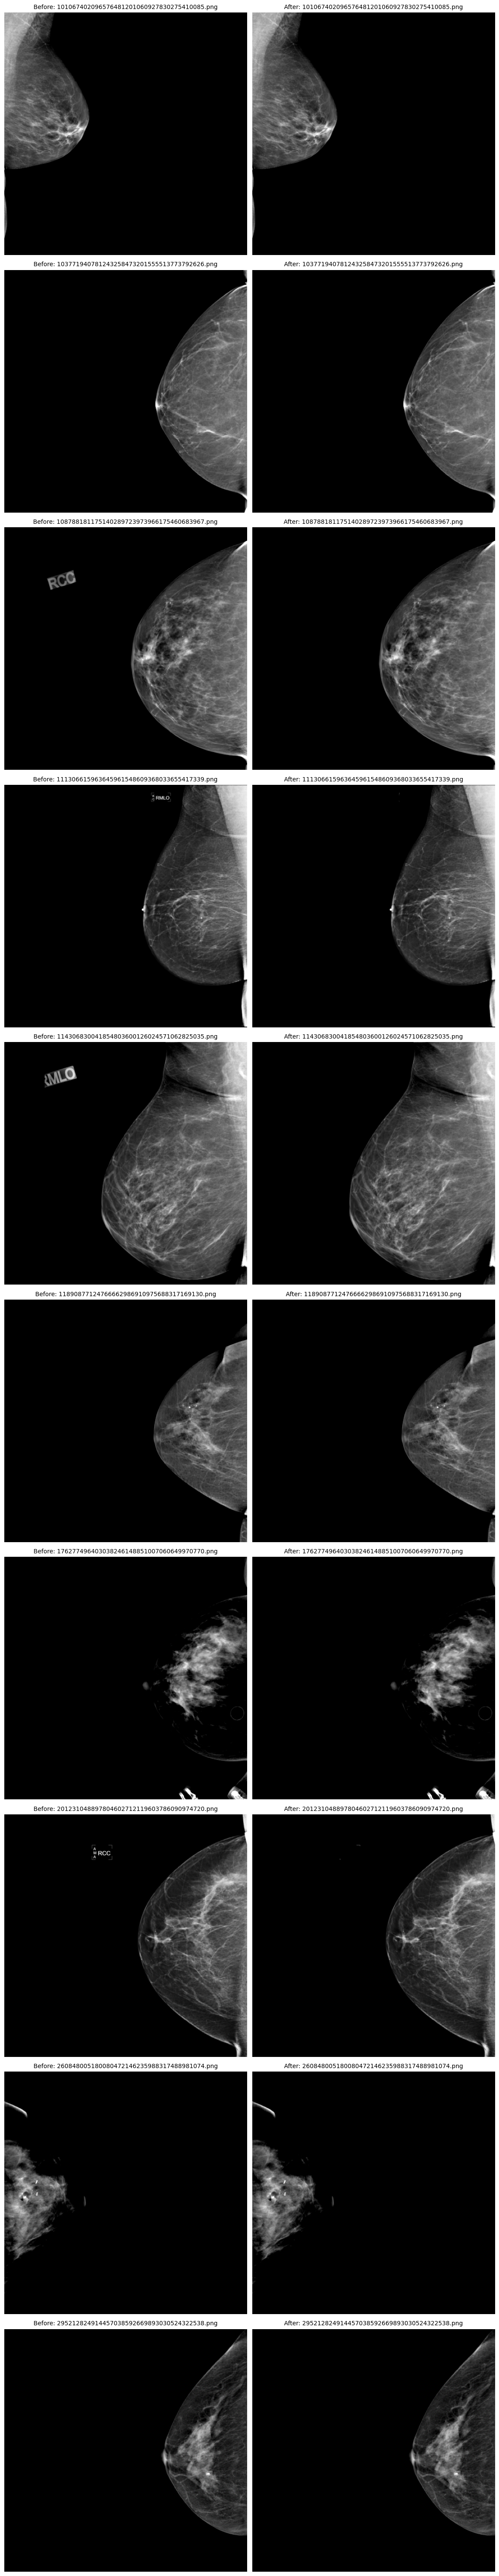

In [50]:
# Process all images and show before/after
cleaned_images = []

for i, orig_file in enumerate(original_files):
    orig = cv2.imread(orig_file, cv2.IMREAD_GRAYSCALE)
    cleaned = remove_text_annotations(orig, pipeline)
    cleaned_images.append(cleaned)
    
    if not np.array_equal(orig, cleaned):
        print(f"{i+1}: {os.path.basename(orig_file)} - text removed")
    else:
        print(f"{i+1}: {os.path.basename(orig_file)} - no text detected")

print(f"\nProcessed {len(cleaned_images)} images")

# Show before and after for all 10 images
fig, axes = plt.subplots(len(original_files), 2, figsize=(12, 6 * len(original_files)))

for i in range(len(original_files)):
    orig = cv2.imread(original_files[i], cv2.IMREAD_GRAYSCALE)
    cleaned = cleaned_images[i]
    filename = os.path.basename(original_files[i])
    
    axes[i, 0].imshow(orig, cmap='gray')
    axes[i, 0].set_title(f'Before: {filename}', fontsize=10)
    axes[i, 0].axis('off')
    
    axes[i, 1].imshow(cleaned, cmap='gray')
    axes[i, 1].set_title(f'After: {filename}', fontsize=10)
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()


In [ ]:
# Detect breast side and mirror images to orient all breasts to the left
def detect_breast_side(img):
    # Detect breast region
    breast_mask = detect_breast_region(img)
    
    # Split image into left and right halves
    h, w = img.shape
    mid_x = w // 2
    
    # Count breast tissue pixels in left and right halves
    left_half = breast_mask[:, :mid_x]
    right_half = breast_mask[:, mid_x:]
    
    left_tissue = np.sum(left_half > 0)
    right_tissue = np.sum(right_half > 0)
    
    # Return 'left' if more tissue on left, 'right' if more on right
    if left_tissue > right_tissue:
        return 'left'
    else:
        return 'right'

# Mirror images that have breast on the right side
mirrored_images = []
breast_sides = []

for i, cleaned_img in enumerate(cleaned_images):
    side = detect_breast_side(cleaned_img)
    breast_sides.append(side)
    
    if side == 'right':
        # Flip horizontally to move breast to left
        mirrored = cv2.flip(cleaned_img, 1)
        mirrored_images.append(mirrored)
        print(f"{i+1}: {os.path.basename(original_files[i])} - breast on {side}, mirrored")
    else:
        # Keep as is
        mirrored_images.append(cleaned_img.copy())
        print(f"{i+1}: {os.path.basename(original_files[i])} - breast on {side}, no mirroring needed")

print(f"\nMirrored {sum(1 for s in breast_sides if s == 'right')} images")


In [ ]:
# Compare before and after mirroring
fig, axes = plt.subplots(len(cleaned_images), 2, figsize=(12, 6 * len(cleaned_images)))

for i in range(len(cleaned_images)):
    before = cleaned_images[i]
    after = mirrored_images[i]
    filename = os.path.basename(original_files[i])
    side = breast_sides[i]
    
    axes[i, 0].imshow(before, cmap='gray')
    axes[i, 0].set_title(f'Before Mirroring ({side}): {filename}', fontsize=10)
    axes[i, 0].axis('off')
    
    axes[i, 1].imshow(after, cmap='gray')
    axes[i, 1].set_title(f'After Mirroring (left): {filename}', fontsize=10)
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()


In [ ]:
# Compare mirrored original images with synthetic images
synthetic_path = "/hpcstor6/scratch01/a/a.kanamarlapudi001/synthetic_classifier/data_10samples/synthetic_fd"
synthetic_files = sorted(glob.glob(os.path.join(synthetic_path, "*.png")))

print(f"Found {len(synthetic_files)} synthetic images")
print(f"Comparing {len(mirrored_images)} mirrored original images with synthetic images\n")

# Show comparison
fig, axes = plt.subplots(len(mirrored_images), 2, figsize=(12, 6 * len(mirrored_images)))

for i in range(len(mirrored_images)):
    mirrored_orig = mirrored_images[i]
    orig_filename = os.path.basename(original_files[i])
    
    # Try to find matching synthetic image by filename, or use index
    if i < len(synthetic_files):
        synthetic_img = cv2.imread(synthetic_files[i], cv2.IMREAD_GRAYSCALE)
        synthetic_filename = os.path.basename(synthetic_files[i])
    else:
        synthetic_img = np.zeros_like(mirrored_orig)
        synthetic_filename = "not found"
    
    axes[i, 0].imshow(mirrored_orig, cmap='gray')
    axes[i, 0].set_title(f'Mirrored Original: {orig_filename}', fontsize=10)
    axes[i, 0].axis('off')
    
    axes[i, 1].imshow(synthetic_img, cmap='gray')
    axes[i, 1].set_title(f'Synthetic: {synthetic_filename}', fontsize=10)
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()


1/1 [==============================] - 0s 167ms/step
Problematic image: 108788181175140289723973966175460683967.png
Image dimensions: 512x512

OCR detected 1 text regions:

  Text: 'rcc'
    Center: (121, 112)
    Bounding box: (86, 88) to (156, 136)
    Size: 70x48
    Location checks:
      In top-left corner: True
      In top-right corner: False
      In bottom-left corner: False
      In bottom-right corner: False
      In top edge: False
      In left edge: False
      In right edge: False
      In center region (skipped): True
      Too large (skipped): False
    Would remove: False



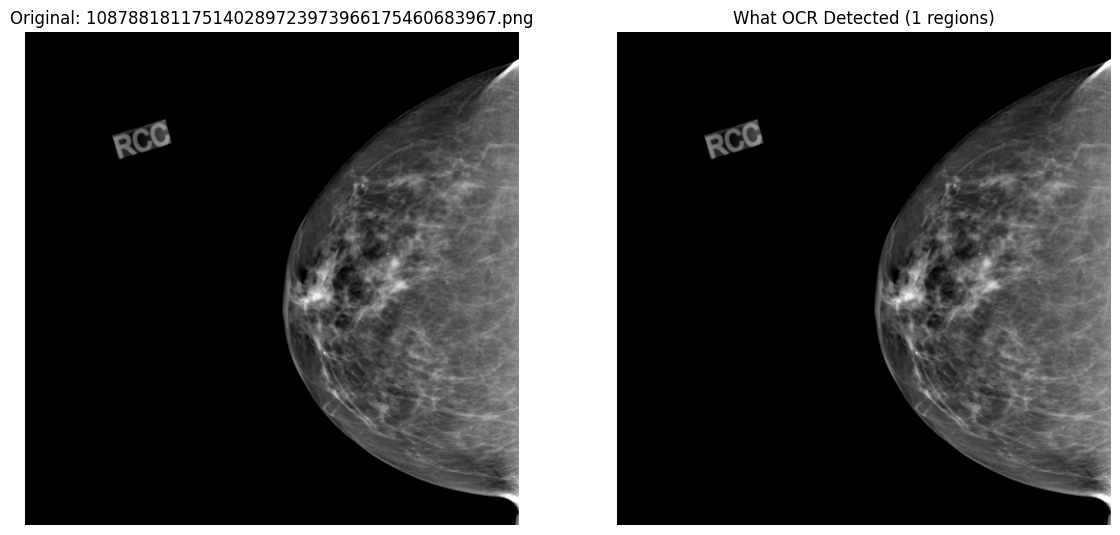

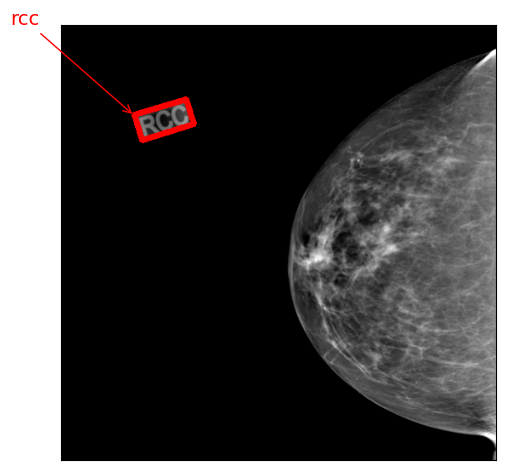

In [51]:
# Diagnostic: Check what OCR detects in the problematic image (image 3 with RCC annotation)
problem_idx = 2  # Image 3 in the list
problem_file = original_files[problem_idx]

test_img = cv2.imread(problem_file, cv2.IMREAD_GRAYSCALE)
test_img_rgb = cv2.cvtColor(test_img, cv2.COLOR_GRAY2RGB)
h, w = test_img.shape

# Run OCR detection
predictions = pipeline.recognize([test_img_rgb])

print(f"Problematic image: {os.path.basename(problem_file)}")
print(f"Image dimensions: {h}x{w}")
print(f"\nOCR detected {len(predictions[0])} text regions:\n")

if len(predictions[0]) == 0:
    print("  No text detected by OCR at all!")
else:
    for word, box in predictions[0]:
        x_coords = [box[0][0], box[1][0], box[2][0], box[3][0]]
        y_coords = [box[0][1], box[1][1], box[2][1], box[3][1]]
        center_x = int(np.mean(x_coords))
        center_y = int(np.mean(y_coords))
        x_min = int(min(x_coords))
        x_max = int(max(x_coords))
        y_min = int(min(y_coords))
        y_max = int(max(y_coords))
        box_width = x_max - x_min
        box_height = y_max - y_min
        
        print(f"  Text: '{word}'")
        print(f"    Center: ({center_x}, {center_y})")
        print(f"    Bounding box: ({x_min}, {y_min}) to ({x_max}, {y_max})")
        print(f"    Size: {box_width}x{box_height}")
        
        # Check why it might be skipped
        corner_h = 200
        corner_w = 250
        in_top_left = y_max < corner_h and x_max < corner_w
        in_top_right = y_max < corner_h and x_min > (w - corner_w)
        in_bottom_left = y_min > (h - corner_h) and x_max < corner_w
        in_bottom_right = y_min > (h - corner_h) and x_min > (w - corner_w)
        in_top_edge = y_max < 150 and corner_w <= x_min and x_max <= (w - corner_w)
        in_left_edge = x_max < 150 and corner_h <= y_min and y_max <= (h - corner_h)
        in_right_edge = x_min > (w - 150) and corner_h <= y_min and y_max <= (h - corner_h)
        in_center = (center_x > 0.2 * w and center_x < 0.8 * w) and (center_y > 0.2 * h and center_y < 0.8 * h)
        too_large = box_width > 150 or box_height > 150
        
        print(f"    Location checks:")
        print(f"      In top-left corner: {in_top_left}")
        print(f"      In top-right corner: {in_top_right}")
        print(f"      In bottom-left corner: {in_bottom_left}")
        print(f"      In bottom-right corner: {in_bottom_right}")
        print(f"      In top edge: {in_top_edge}")
        print(f"      In left edge: {in_left_edge}")
        print(f"      In right edge: {in_right_edge}")
        print(f"      In center region (skipped): {in_center}")
        print(f"      Too large (skipped): {too_large}")
        
        would_remove = (in_top_left or in_top_right or in_bottom_left or in_bottom_right or 
                       in_top_edge or in_left_edge or in_right_edge) and not in_center and not too_large
        print(f"    Would remove: {would_remove}\n")

# Visualize OCR detection
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes[0].imshow(test_img, cmap='gray')
axes[0].set_title(f'Original: {os.path.basename(problem_file)}')
axes[0].axis('off')

if len(predictions[0]) > 0:
    annotated = test_img_rgb.copy()
    keras_ocr.tools.drawAnnotations(image=annotated, predictions=predictions[0])
    axes[1].imshow(cv2.cvtColor(annotated, cv2.COLOR_RGB2BGR))
    axes[1].set_title(f'What OCR Detected ({len(predictions[0])} regions)')
else:
    axes[1].imshow(test_img, cmap='gray')
    axes[1].set_title('OCR Detected Nothing')
axes[1].axis('off')

plt.tight_layout()
plt.show()


1/1 [==============================] - 0s 164ms/step
First image: 101067402096576481201060927830275410085.png
OCR detected 1 text regions:
  'ss' at center (118, 253), bbox: (90, 234) to (146, 272)


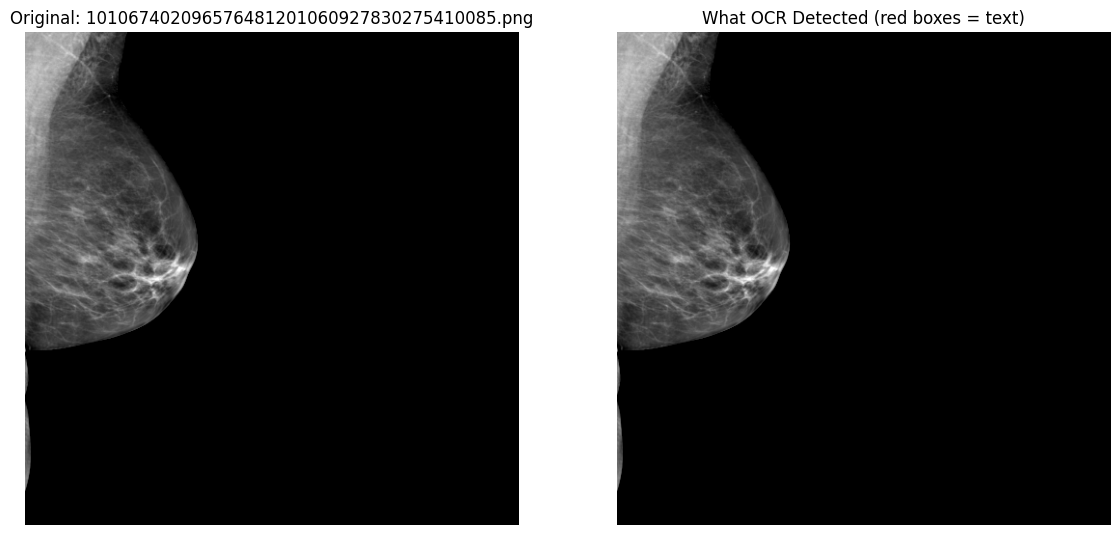

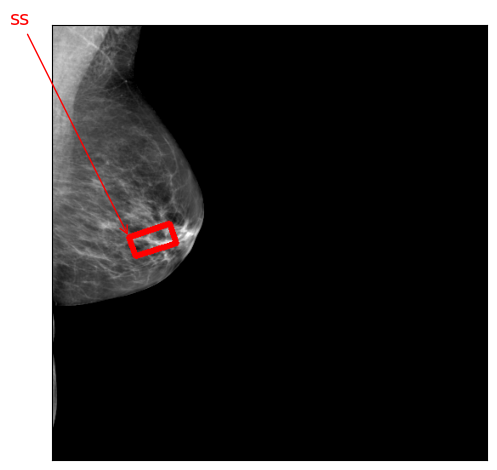

In [52]:
# Check what OCR detects in first image to understand the issue
test_img = cv2.imread(original_files[0], cv2.IMREAD_GRAYSCALE)
test_img_rgb = cv2.cvtColor(test_img, cv2.COLOR_GRAY2RGB)
predictions = pipeline.recognize([test_img_rgb])

print(f"First image: {os.path.basename(original_files[0])}")
print(f"OCR detected {len(predictions[0])} text regions:")
for word, box in predictions[0]:
    x_coords = [box[0][0], box[1][0], box[2][0], box[3][0]]
    y_coords = [box[0][1], box[1][1], box[2][1], box[3][1]]
    center_x = int(np.mean(x_coords))
    center_y = int(np.mean(y_coords))
    x_min = int(min(x_coords))
    x_max = int(max(x_coords))
    y_min = int(min(y_coords))
    y_max = int(max(y_coords))
    print(f"  '{word}' at center ({center_x}, {center_y}), bbox: ({x_min}, {y_min}) to ({x_max}, {y_max})")

# Show OCR detection results
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes[0].imshow(test_img, cmap='gray')
axes[0].set_title(f'Original: {os.path.basename(original_files[0])}')
axes[0].axis('off')

annotated = test_img_rgb.copy()
keras_ocr.tools.drawAnnotations(image=annotated, predictions=predictions[0])
axes[1].imshow(cv2.cvtColor(annotated, cv2.COLOR_RGB2BGR))
axes[1].set_title('What OCR Detected (red boxes = text)')
axes[1].axis('off')

plt.tight_layout()
plt.show()
